# 04. Downscaling land surface temperature to 100 m

Sentinel-3 sees temperature at 1 km; Sentinel-2 sees the surface at 10 to 20 m. Downscaling learns, for each Sentinel-3 scene, how temperature relates to what Sentinel-2 and the terrain show at 1 km, applies that relation at 100 m, and then corrects the result so that it averages back to the observed 1 km scene.

This notebook, on real data over Berlin, August 2026:

1. runs the whole chain from one request (`DownscaleSpec`);
2. shows observed and sharpened scenes, and checks that the sharpened ones conserve the observation;
3. validates the 100 m result against an **independent** Landsat 9/8 temperature measured at 100 m the same morning;
4. compares models (linear, Random Forest, XGBoost, local-window trees, TsHARP) with a blocked spatial holdout;
5. adds prediction intervals with conformal calibration;
6. fuses Landsat and Sentinel-3 in time with STARFM and ESTARFM;
7. writes the sharpened maps as GeoTIFF.

Read `docs/downscaling.md` for the method, the literature and the multi-city benchmark behind the defaults used here.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import dotenv_values, load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "notebooks"
WORK = OUT / "work"  # shared download/subset cache: later notebooks reuse it
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Credentials live in the repository's .env (see docs/setup.md). The
# Earthdata token is often kept only in worker/.env; fall back to it.
load_dotenv(ROOT / ".env")
if not os.getenv("EARTHDATA_BEARER_TOKEN"):
    token = dotenv_values(ROOT / "worker" / ".env").get("EARTHDATA_BEARER_TOKEN")
    if token:
        os.environ["EARTHDATA_BEARER_TOKEN"] = token

# Upstream notices (numpy/xarray/matplotlib internals, all-NaN slices of
# cloudy scenes) that say nothing about the analysis.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "image.origin": "upper"})
pd.set_option("display.max_colwidth", 70)

In [2]:
def extent_km(da):
    """imshow extent of a projected y/x grid, in kilometres."""
    x, y = da["x"].values, da["y"].values
    dx, dy = abs(x[1] - x[0]), abs(y[1] - y[0])
    return [(x.min() - dx / 2) / 1e3, (x.max() + dx / 2) / 1e3, (y.min() - dy / 2) / 1e3, (y.max() + dy / 2) / 1e3]


def show_map(ax, da, title, cmap="inferno", label=None, vmin=None, vmax=None):
    """One georeferenced map with a colour bar; axes in UTM kilometres."""
    image = ax.imshow(da.values, extent=extent_km(da), cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("easting (km)")
    ax.set_ylabel("northing (km)")
    plt.colorbar(image, ax=ax, shrink=0.8, label=label or da.attrs.get("units", ""))
    return image

In [3]:
import dataclasses
import logging

import citycube as cc

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
for noisy in ("httpx", "rasterio", "urllib3", "openeo"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

## 1. One request, end to end

* Sentinel-3 daytime passes are the 1 km target.
* Sentinel-2 L2A, read as cloud-optimised GeoTIFFs, gives NDVI, NDBI, EVI and NDMI at 100 m.
* Terrain adds elevation, slope and the solar illumination of each slope at the Sentinel-3 overpass time.
* Landsat 8/9 is requested only as an independent reference for validation; it is never used for training.
* `DownscaleSpec()` turns on per-scene downscaling: one model per Sentinel-3 scene, trained on that scene alone. The default model, `"local_trees"`, combines a city-wide model with local models in moving 10 km windows, so the relation between NDVI and temperature may differ between the centre and the outskirts.

Two defaults matter for how the maps look. The coarse correction is **smooth**: the residual between the observed 1 km scene and the averaged model is interpolated and applied iteratively, so the result conserves the observation without 1 km steps (`correction="block"` gives the classic stepwise version). And cells under **clouds** stay empty (`mask_unobserved=True`): the model could predict a clear-sky temperature there, but nothing was observed.

In [4]:
berlin = cc.get_city("berlin")
request = cc.AnalysisRequest.for_city(berlin, "2026-08-01", "2026-08-21", sensors=("sentinel3", "sentinel2", "landsat"), resolution_m=100, max_products_per_sensor=20)
request = dataclasses.replace(
    request,
    sentinel2_source="stac_cog",
    s2_cloud_cover_max=60,
    thermal_overpass="day",
    terrain_predictors=True,
    temporal_tolerances={"landsat": np.timedelta64(1, "D")},
    downscale=cc.DownscaleSpec(),
)
result = cc.AnalysisWorkflow(request).execute(WORK)
cube, downscaled, terrain = result.cube, result.downscaled, result.terrain
predictors, landsat = result.predictors["sentinel2"], result.predictors["landsat"]  # one 100 m cube per sensor

print("coarse cube:", dict(cube.sizes), "| Sentinel-2:", dict(predictors.sizes), "| downscaled:", dict(downscaled.sizes))
result.provenance["downscaling"]

INFO citycube.workflow.runner: sentinel3: 40 candidate products, 37 cover at least 30% of the AOI, 20 selected


INFO citycube.workflow.runner: sentinel2: 19 candidate products, 17 cover at least 30% of the AOI, 17 selected


INFO citycube.workflow.runner: landsat: 6 candidate products, 6 cover at least 30% of the AOI, 6 selected


INFO citycube.workflow.runner: sentinel3: acquiring 20 products


INFO citycube.workflow.runner: sentinel3: prepared 20 acquisitions


...

INFO citycube.workflow.runner: Downscaling 20 scenes per scene with local_trees


WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


INFO citycube.workflow.runner: Fused cube: 20 times, 37 variables


coarse cube: {'time': 20, 'y': 22, 'x': 25} | Sentinel-2: {'time': 6, 'y': 206, 'x': 243} | downscaled: {'x': 243, 'time': 15, 'y': 206}


{'protocol': 'per_scene',
 'model': 'local_trees',
 'predictors': ['NDVI',
  'NDBI',
  'EVI',
  'NDMI',
  'elevation',
  'slope',
  'cos_incidence'],
 'scenes': 15,
 'skipped_scenes': ['2026-08-04T09:24:12: Only 0 complete samples; need at least 30',
  '2026-08-04T10:02:53: Only 0 complete samples; need at least 30',
  '2026-08-09T08:54:17: Only 0 complete samples; need at least 30',
  '2026-08-16T09:51:40: Only 0 complete samples; need at least 30',
  '2026-08-18T10:01:36: Only 0 complete samples; need at least 30']}

Each downscaled scene carries the sharpened temperature, the model's raw prediction before the coarse correction, an uncertainty, the correction applied, a support mask and a flag for cells whose predictors lie outside the range seen in training:

In [5]:
pd.DataFrame([{"variable": name, "dims": ", ".join(var.dims), "units": var.attrs.get("units", "")} for name, var in downscaled.data_vars.items()])

,variable,dims,units
0,downscaled_support,"time, y, x",
1,coarse_observed,"time, y, x",
2,coarse_consistency_rmse,time,
3,downscaling_training_samples,time,
4,lst_downscaled_uncertainty,"time, y, x",K
5,lst_downscaled_raw,"time, y, x",degC
6,coarse_consistency_correction,"time, y, x",K
7,lst_downscaled,"time, y, x",degC


## 2. Observed and sharpened

The clearest scene: the 1 km observation, the 100 m result, the NDVI the model leaned on, and the coarse correction that makes the result conserve the observation.

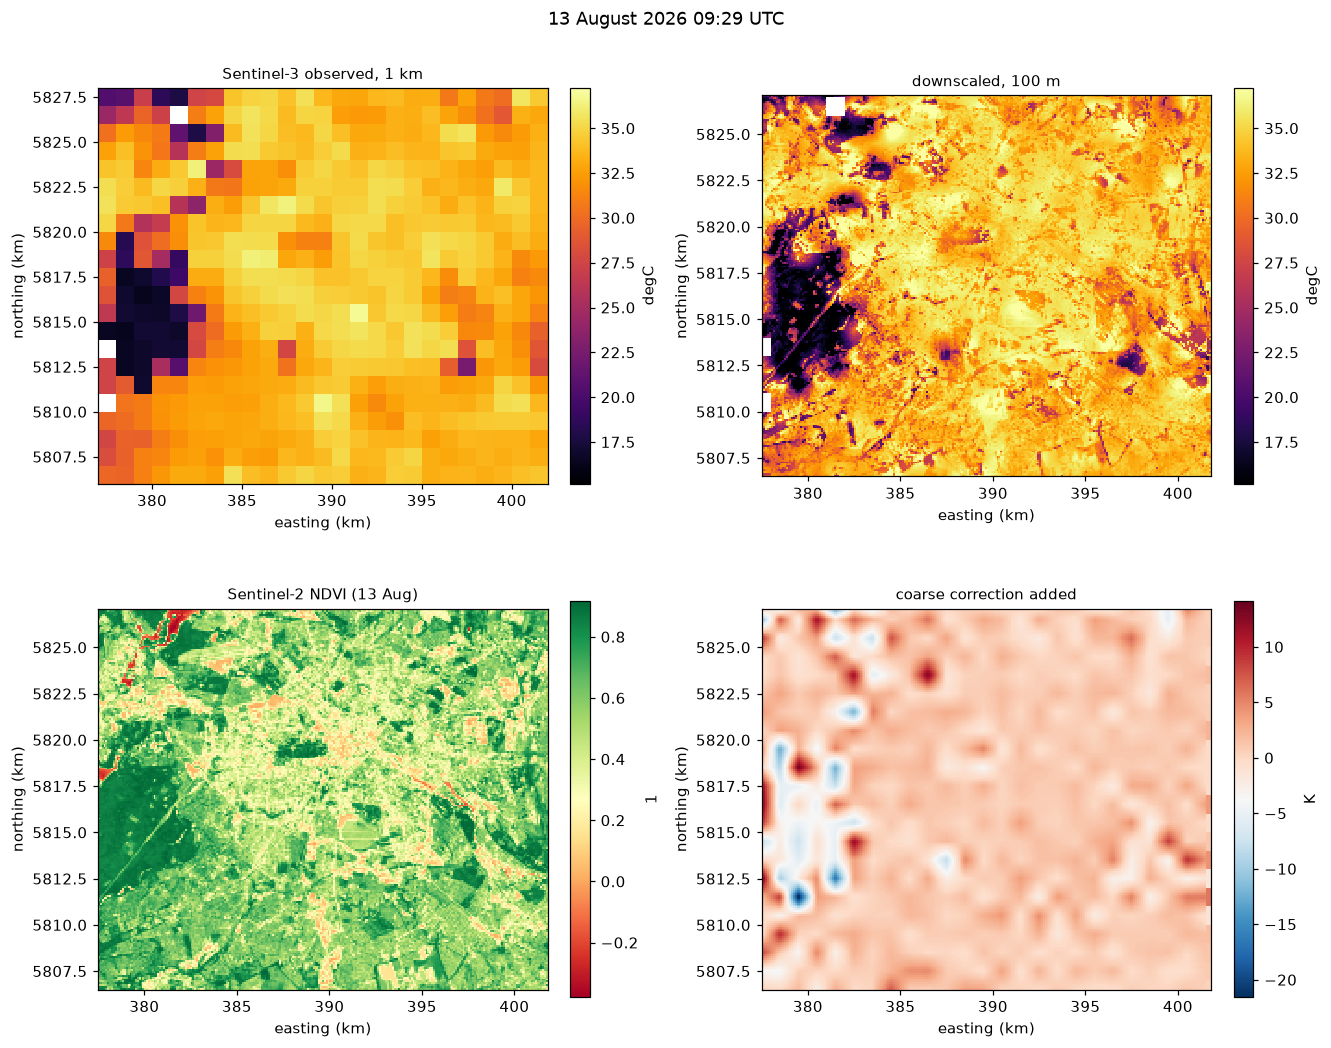

In [6]:
coverage = downscaled["lst_downscaled"].notnull().mean(["y", "x"])
index = int(coverage.argmax())
when = downscaled.time.values[index]
scene = downscaled.isel(time=index)
matched = cube["sentinel2_matched_time"].sel(time=when).values
low, high = np.nanpercentile(scene["lst_downscaled"].values, [2, 98])

fig, axes = plt.subplots(2, 2, figsize=(12, 9.5), constrained_layout=True)
show_map(axes[0, 0], cube["lst"].sel(time=when), "Sentinel-3 observed, 1 km", label="degC", vmin=low, vmax=high)
show_map(axes[0, 1], scene["lst_downscaled"], "downscaled, 100 m", label="degC", vmin=low, vmax=high)
show_map(axes[1, 0], predictors["NDVI"].sel(time=matched), f"Sentinel-2 NDVI ({pd.Timestamp(matched):%d %b})", cmap="RdYlGn", label="")
show_map(axes[1, 1], scene["coarse_consistency_correction"], "coarse correction added", cmap="RdBu_r", label="K")
fig.suptitle(f"{pd.Timestamp(when):%d %B %Y %H:%M} UTC")
fig.savefig(FIGURES / "04_downscaled_scene.png", bbox_inches="tight")
plt.show()

### A closer look

A 6 x 6 km window over the city centre and Tempelhof. The 1 km pixels become streets, parks, the former airfield and the Spree.

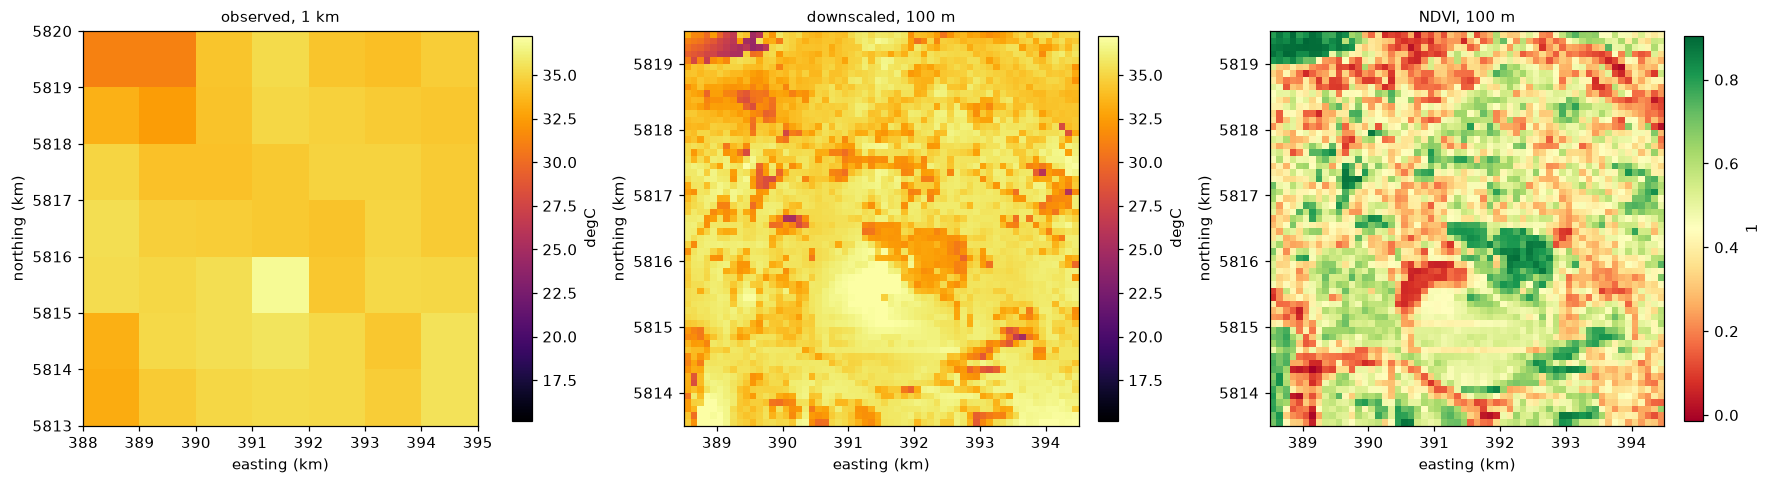

In [7]:
cx, cy = 391_500, 5_816_500  # Tempelhof / Kreuzberg, UTM 33N
window = dict(x=slice(cx - 3000, cx + 3000), y=slice(cy + 3000, cy - 3000))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
show_map(axes[0], cube["lst"].sel(time=when).sel(**window), "observed, 1 km", label="degC", vmin=low, vmax=high)
show_map(axes[1], scene["lst_downscaled"].sel(**window), "downscaled, 100 m", label="degC", vmin=low, vmax=high)
show_map(axes[2], predictors["NDVI"].sel(time=matched).sel(**window), "NDVI, 100 m", cmap="RdYlGn", label="")
plt.show()

### Does the result conserve the observation?

Averaging the 100 m result back onto the 1 km grid should give the observed scene. `coarse_consistency_rmse` is that error per scene, before (raw model) and after the correction.

In [8]:
raw_rmse, corrected_rmse = [], []
for t in downscaled.time.values:
    observed = cube["lst"].sel(time=t)
    for name, store in (("lst_downscaled_raw", raw_rmse), ("lst_downscaled", corrected_rmse)):
        aggregated = cc.reaggregate_to_target(downscaled[name].sel(time=t).assign_attrs(crs=cube.attrs["crs"]), observed.assign_attrs(crs=cube.attrs["crs"]))
        store.append(cc.compare_to_reference(aggregated, observed)["rmse"])
conservation = pd.DataFrame({"raw model": raw_rmse, "after correction": corrected_rmse}, index=pd.DatetimeIndex(downscaled.time.values, name="scene")).round(3)
conservation

,raw model,after correction
scene,,
2026-08-02 10:16:35.048924,2.195,0.021
2026-08-03 09:50:23.896256,1.619,0.024
2026-08-05 09:36:42.351631,1.885,0.018
2026-08-06 10:12:49.598361,1.305,0.007
2026-08-08 09:59:08.810295,2.582,0.032
2026-08-09 09:32:57.922360,2.242,0.027
2026-08-10 10:09:05.372192,0.882,0.002
2026-08-11 09:42:54.478075,2.058,0.015
2026-08-12 09:16:43.586937,1.659,0.024


## 3. Independent validation against Landsat

Landsat 8 and 9 measure temperature at 100 m (resampled from their 30 m product). Where a Landsat pass and a Sentinel-3 pass fall on the same morning, the downscaled map can be compared with a real, independent 100 m observation.

Two sensors never agree exactly in absolute terms (different overpass minute, viewing angle and emissivity assumptions), so we look at both the plain error and the *spatial pattern*: correlation and the error after removing each map's mean. The baseline is the 1 km Sentinel-3 scene simply repeated at 100 m: downscaling is worth it only if it beats that.

In [9]:
landsat_times = [t for t in landsat.time.values if landsat["landsat_lst"].sel(time=t).notnull().mean() > 0.5]
rows, pairs = [], []
for t_landsat in landsat_times:
    nearest = downscaled.time.values[np.argmin(np.abs(downscaled.time.values - t_landsat))]
    if abs(nearest - t_landsat) > np.timedelta64(3, "h"):
        continue
    reference = landsat["landsat_lst"].sel(time=t_landsat)
    sharpened = downscaled["lst_downscaled"].sel(time=nearest)
    upsampled = cube["lst"].sel(time=nearest).reindex(y=reference.y, x=reference.x, method="nearest")
    for name, estimate in (("downscaled 100 m", sharpened), ("1 km repeated", upsampled)):
        metrics = cc.validate_independent_reference(estimate, reference, reference_name="landsat")
        both = np.isfinite(estimate.values) & np.isfinite(reference.values)
        anomaly = (estimate.values[both] - estimate.values[both].mean()) - (reference.values[both] - reference.values[both].mean())
        rows.append({"Landsat": pd.Timestamp(t_landsat).strftime("%d %b %H:%M"), "Sentinel-3": pd.Timestamp(nearest).strftime("%H:%M"), "estimate": name,
                     "rmse": metrics["rmse"], "bias": metrics["bias"], "correlation": metrics["correlation"], "pattern rmse": float(np.sqrt(np.mean(anomaly**2))), "pixels": int(both.sum())})
    pairs.append((t_landsat, nearest))
validation = pd.DataFrame(rows).round(2)
validation

,Landsat,Sentinel-3,estimate,rmse,bias,correlation,pattern rmse,pixels
0,15 Aug 09:56,09:39,downscaled 100 m,2.07,-1.01,0.66,1.80,34959
1,15 Aug 09:56,09:39,1 km repeated,2.28,-1.01,0.51,2.04,34959


In [10]:
for when, group in validation.groupby("Landsat"):
    sharp, flat = group.set_index("estimate").loc["downscaled 100 m"], group.set_index("estimate").loc["1 km repeated"]
    better = [name for name in ("rmse", "pattern rmse") if sharp[name] < flat[name]] + (["correlation"] if sharp["correlation"] > flat["correlation"] else [])
    print(f"{when}: downscaling beats the repeated 1 km scene on {', '.join(better) if better else 'nothing'} "
          f"(rmse {sharp['rmse']:.2f} vs {flat['rmse']:.2f} K, correlation {sharp['correlation']:.2f} vs {flat['correlation']:.2f})")

15 Aug 09:56: downscaling beats the repeated 1 km scene on rmse, pattern rmse, correlation (rmse 2.07 vs 2.28 K, correlation 0.66 vs 0.51)


How to read this: correlation rewards putting hot roofs and cool parks in the right places; RMSE also counts the offset between the two sensors and any detail the 100 m predictors cannot explain, so the two metrics can disagree. One Landsat scene is a small sample, and the sensors differ by more than resolution: Landsat sees 30 m detail (aggregated here to 100 m) about 15 minutes after Sentinel-3, from a different angle. The multi-city benchmark in `docs/downscaling.md` evaluates on many more scenes.

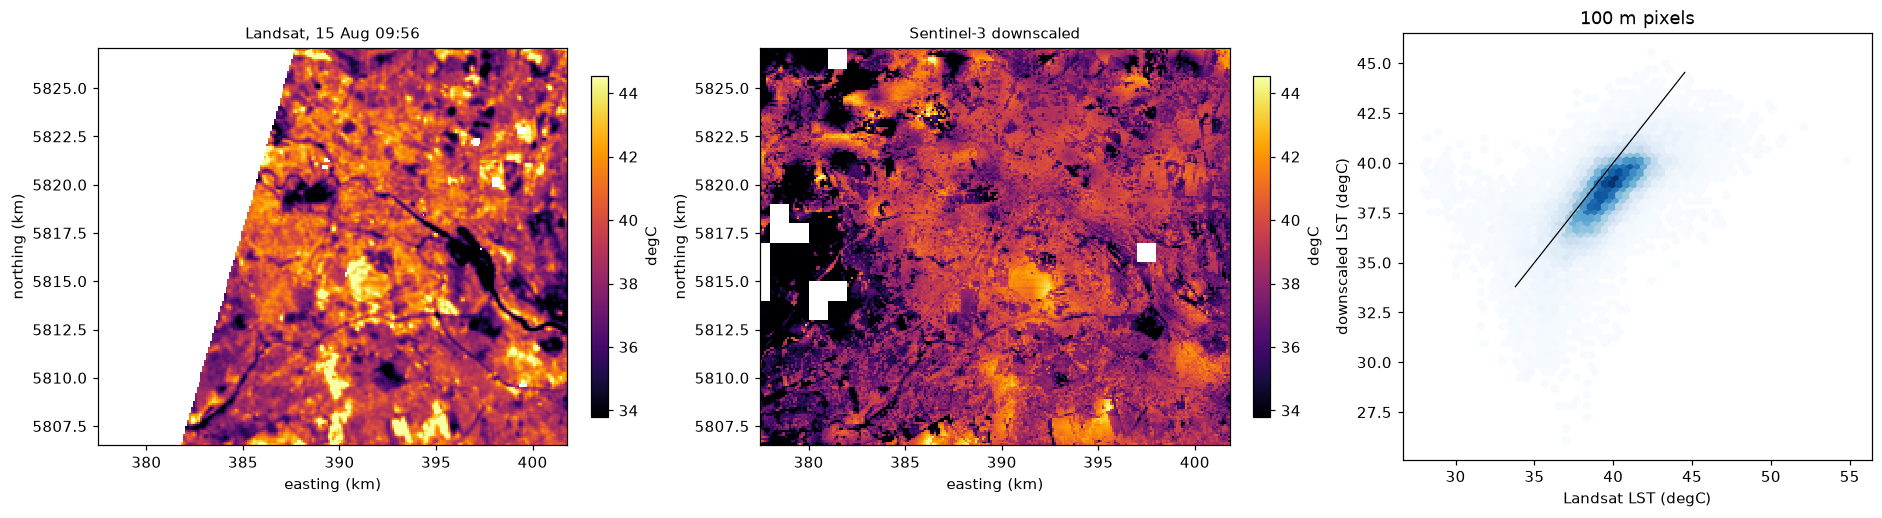

In [11]:
if pairs:
    t_landsat, nearest = pairs[0]
    reference = landsat["landsat_lst"].sel(time=t_landsat)
    sharpened = downscaled["lst_downscaled"].sel(time=nearest)
    v_low, v_high = np.nanpercentile(reference.values, [2, 98])
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    show_map(axes[0], reference, f"Landsat, {pd.Timestamp(t_landsat):%d %b %H:%M}", label="degC", vmin=v_low, vmax=v_high)
    show_map(axes[1], sharpened, "Sentinel-3 downscaled", label="degC", vmin=v_low, vmax=v_high)
    both = np.isfinite(reference.values) & np.isfinite(sharpened.values)
    axes[2].hexbin(reference.values[both], sharpened.values[both], gridsize=60, cmap="Blues", mincnt=1)
    axes[2].plot([v_low, v_high], [v_low, v_high], color="black", lw=0.8)
    axes[2].set_xlabel("Landsat LST (degC)")
    axes[2].set_ylabel("downscaled LST (degC)")
    axes[2].set_title("100 m pixels")
    fig.savefig(FIGURES / "04_landsat_validation.png", bbox_inches="tight")
    plt.show()

## 4. Comparing models with a blocked holdout

To compare models fairly, part of each scene is hidden: a checkerboard of 5 x 5 km blocks. Each model is trained per scene on the visible blocks only, predicts the whole city at 100 m, and is scored after averaging back to 1 km on the hidden blocks, which it never saw. Blocks rather than single pixels matter: neighbouring pixels are so alike that hiding single pixels rewards copying neighbours.

The "no skill" reference predicts each scene's mean temperature everywhere. TsHARP is the classic one-predictor method (temperature against NDVI).

In [12]:
block = 5
ny, nx = cube.sizes["y"], cube.sizes["x"]
rows_index, cols_index = np.indices((ny, nx))
hidden = xr.DataArray(((rows_index // block + cols_index // block) % 2 == 1), dims=("y", "x"), coords={"y": cube.y, "x": cube.x})
training_cube = cube.assign(lst=cube["lst"].where(~hidden))

indices = ["NDVI", "NDBI", "EVI", "NDMI"]
with_terrain = indices + ["elevation", "slope", "cos_incidence"]


def holdout_rmse(model, predictor_names):
    # mask_unobserved=False: the hidden blocks are "unobserved" here on purpose, and are exactly what we score.
    fine = cc.downscale_per_scene(training_cube, predictors, predictors=predictor_names, model=model, terrain=terrain, min_samples=20, mask_unobserved=False)
    aggregated = cc.reaggregate_to_target(fine["lst_downscaled"].assign_attrs(crs=cube.attrs["crs"]), cube["lst"].assign_attrs(crs=cube.attrs["crs"]))
    observed = cube["lst"].sel(time=aggregated.time)
    return cc.compare_to_reference(aggregated.where(hidden), observed.where(hidden))


def tsharp_rmse():
    scores = []
    for t in training_cube.time.values:
        scene_cube = training_cube.sel(time=[t])
        try:
            model = cc.fit_tsharp_downscaler(scene_cube, predictor="NDVI", min_samples=20)
        except cc.CubeValidationError:
            continue
        matched = scene_cube["sentinel2_matched_time"].values[0]
        if np.isnat(matched):
            continue
        fine = model.predict(predictors[["NDVI"]].sel(time=[matched]).assign_coords(time=[t]))
        scores.append(cc.reaggregate_to_target(fine["lst_downscaled"].assign_attrs(crs=cube.attrs["crs"]), cube["lst"].sel(time=[t]).assign_attrs(crs=cube.attrs["crs"])))
    aggregated = xr.concat(scores, "time")
    return cc.compare_to_reference(aggregated.where(hidden), cube["lst"].sel(time=aggregated.time).where(hidden))


scene_means = training_cube["lst"].mean(["y", "x"])
no_skill = cc.compare_to_reference((xr.ones_like(cube["lst"]) * scene_means).where(hidden), cube["lst"].where(hidden))
scores = {("no skill (scene mean)", "-"): no_skill, ("TsHARP", "NDVI"): tsharp_rmse()}
for model in ("linear", "random_forest", "xgboost", "local_trees"):
    for label, names in (("indices", indices), ("indices + terrain", with_terrain)):
        scores[(model, label)] = holdout_rmse(model, names)

comparison = pd.DataFrame({key: {"rmse": value["rmse"], "mae": value["mae"], "correlation": value["correlation"], "cells": value["samples"]} for key, value in scores.items()}).T
comparison.index.names = ["model", "predictors"]
comparison.round(2).sort_values("rmse")

WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


WARNING citycube.downscale.per_scene: Per-scene downscaling skipped 5 of 20 scenes


rmse   mae  correlation   cells
model                 predictors                                        
local_trees           indices            2.02  1.39         0.90  3121.0
                      indices + terrain  2.04  1.44         0.89  3121.0
linear                indices + terrain  2.19  1.53         0.87  3121.0
                      indices            2.20  1.52         0.87  3121.0
xgboost               indices + terrain  2.26  1.70         0.88  3121.0
random_forest         indices            2.26  1.65         0.88  3121.0
xgboost               indices            2.27  1.64         0.87  3121.0
random_forest         indices + terrain  2.31  1.76         0.88  3121.0
TsHARP                NDVI               2.46  1.71         0.83  3121.0
no skill (scene mean) -                  2.86  2.07         0.77  3121.0

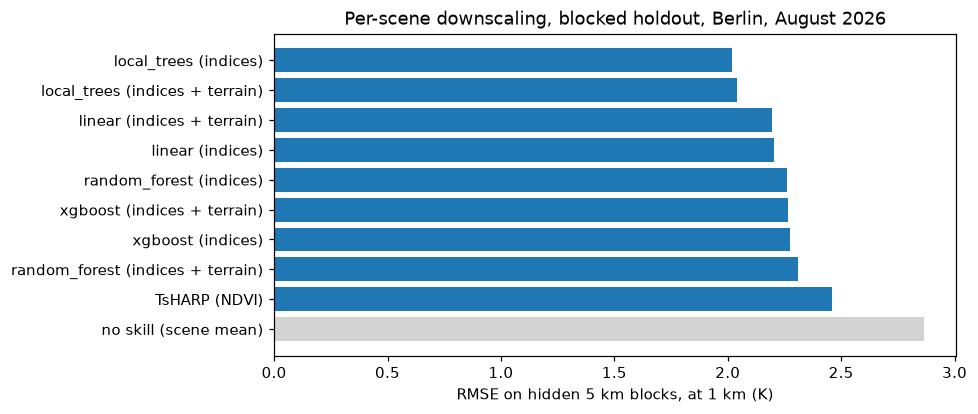

In [13]:
ordered = comparison.sort_values("rmse")
fig, ax = plt.subplots(figsize=(8, 3.8))
labels = [f"{m} ({p})" if p != "-" else m for m, p in ordered.index]
colours = ["lightgrey" if m.startswith("no skill") else "tab:blue" for m, _ in ordered.index]
ax.barh(labels, ordered["rmse"], color=colours)
ax.invert_yaxis()
ax.set_xlabel("RMSE on hidden 5 km blocks, at 1 km (K)")
ax.set_title("Per-scene downscaling, blocked holdout, Berlin, August 2026")
fig.savefig(FIGURES / "04_model_comparison.png", bbox_inches="tight")
plt.show()

## 5. Prediction intervals

`fit_conformal_downscaler` wraps a fitted model with split-conformal intervals: it measures the model's errors on calibration cells it was not trained on, and widens or narrows each interval with the Random Forest's own tree spread. Here a model pooled over all training scenes is used, since conformal calibration needs many calibration cells.

**Caveat:** on real data these 90 % intervals are not yet calibrated (the multi-city benchmark measured 42 to 93 % coverage), because a pooled model's errors include each day's temperature offset. The empirical coverage below says how far off they are here.

In [14]:
split = dict(validation_fraction=0.3, spatial_block_period=2, block_size=5)
train, validation_cube = cc.blocked_spatiotemporal_split(cube, **split)
calibration = cc.blocked_calibration_split(cube, **split)
static = ["NDVI", "NDBI", "EVI", "NDMI", "elevation", "slope"]

forest = cc.fit_random_forest_downscaler(train, predictors=static, min_samples=50)
conformal = cc.fit_conformal_downscaler(forest, calibration, alpha=0.1)
metrics = cc.validate_downscaler(conformal, validation_cube)
print(f"nominal coverage 90 %, empirical {metrics['interval_coverage']:.0%}, mean width {metrics['interval_mean_width']:.1f} K, pooled-model bias {metrics['bias']:+.1f} K")
{key: round(value, 3) if isinstance(value, float) else value for key, value in metrics.items()}

nominal coverage 90 %, empirical 28%, mean width 9.4 K, pooled-model bias -4.6 K


{'variable': 'lst',
 'samples': 831,
 'bias': -4.63,
 'mae': 5.802,
 'rmse': 6.2,
 'correlation': 0.383,
 'interval_coverage': 0.283,
 'interval_mean_width': 9.418}

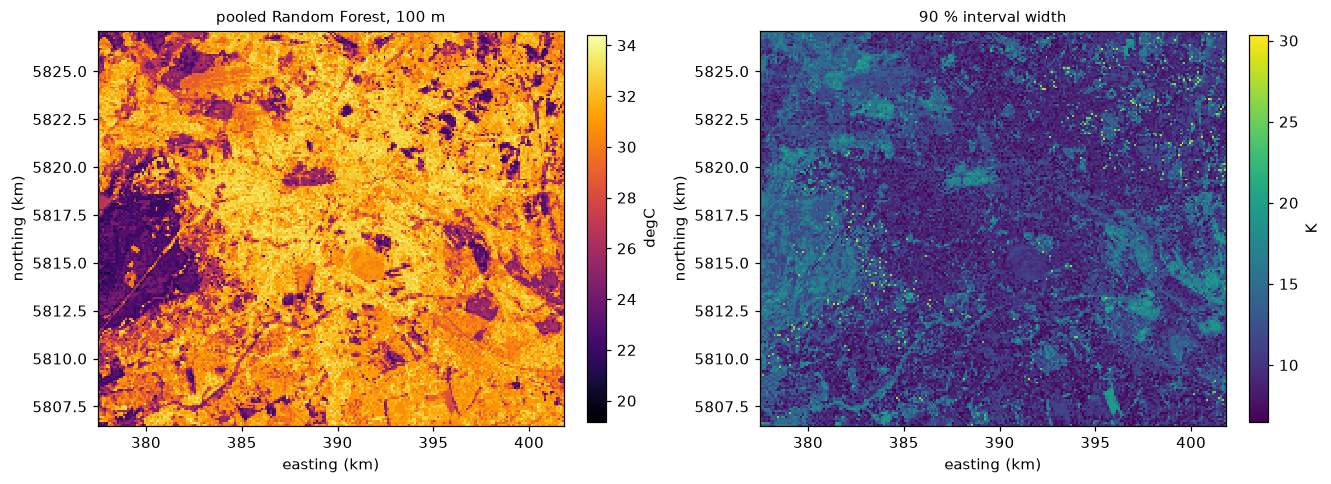

In [15]:
# Static terrain is kept once in result.terrain, not repeated for every Sentinel-2 date.
fine_static = predictors[static[:4]].sel(time=[matched]).assign(
    {name: terrain[name].reindex(y=predictors.y, x=predictors.x, method="nearest", tolerance=1e-6).expand_dims(time=[matched]) for name in ("elevation", "slope")}
)
intervals = conformal.predict(fine_static)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
show_map(axes[0], intervals["lst_downscaled"].isel(time=0), "pooled Random Forest, 100 m", label="degC")
show_map(axes[1], (intervals["lst_downscaled_upper"] - intervals["lst_downscaled_lower"]).isel(time=0), "90 % interval width", cmap="viridis", label="K")
plt.show()

## 6. Fusing in time: STARFM and ESTARFM

Landsat gives 100 m but only every 8 days and often cloudy; Sentinel-3 gives 1 km daily. STARFM predicts a 100 m map for a day without Landsat from a Landsat scene at t0 plus the Sentinel-3 change between t0 and t1. ESTARFM uses two Landsat scenes bracketing t1 and learns a local relation between fine and coarse change.

August had only one clear Landsat pass over Berlin, so a separate request covers mid-August to September: Sentinel-3 and Landsat only. STARFM then predicts the last clear Landsat date from the first, and the real Landsat scene of that date is the check.

In [16]:
pair_request = dataclasses.replace(
    request, sensors=("sentinel3", "landsat"), start="2026-08-10", end="2026-09-20",
    downscale=None, terrain_predictors=False, max_products_per_sensor=40,
)
pair_result = cc.AnalysisWorkflow(pair_request).execute(WORK)
fine_stack, coarse_stack = pair_result.predictors["landsat"]["landsat_lst"], pair_result.cube["lst"]

coverage_l = fine_stack.notnull().mean(["y", "x"]).to_series()
best_per_day = coverage_l.groupby(coverage_l.index.normalize()).idxmax()
clear_days = [t for day, t in best_per_day.items() if coverage_l[t] > 0.4]
print("clear Landsat passes:", [f"{pd.Timestamp(t):%d %b} ({coverage_l[t]:.0%})" for t in clear_days])

INFO citycube.workflow.runner: sentinel3: 82 candidate products, 76 cover at least 30% of the AOI, 40 selected


INFO citycube.workflow.runner: landsat: 18 candidate products, 18 cover at least 30% of the AOI, 18 selected


INFO citycube.workflow.runner: sentinel3: acquiring 40 products


INFO citycube.workflow.runner: sentinel3: prepared 40 acquisitions


INFO citycube.workflow.runner: landsat: acquiring 18 products


INFO citycube.workflow.runner: landsat: prepared 18 acquisitions


INFO citycube.workflow.runner: Fused cube: 40 times, 19 variables


clear Landsat passes: ['15 Aug (70%)', '31 Aug (40%)', '15 Sep (72%)']


STARFM 15 Aug -> 15 Sep: rmse 2.39 K, r 0.69
reusing the 15 Aug Landsat scene unchanged: rmse 12.92 K, r 0.78


ESTARFM for 27 Aug: 5 of 27368 pixels (0.018%) outside -10 to 70 degC, from -56 to 63 degC


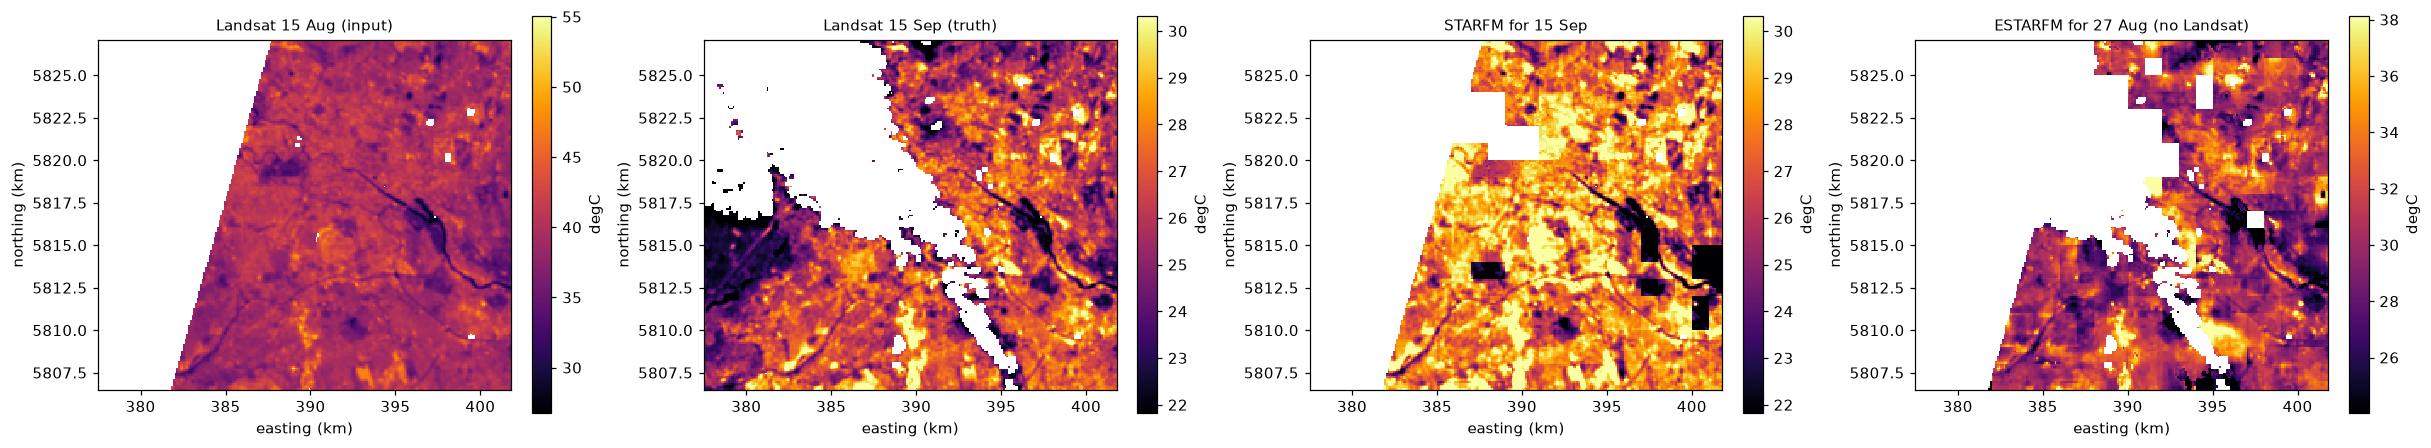

In [17]:
def coarse_near(t, max_hours=3):
    """The clearest Sentinel-3 daytime scene within a few hours of t."""
    window = coarse_stack.sel(time=slice(t - np.timedelta64(max_hours, "h"), t + np.timedelta64(max_hours, "h")))
    if window.sizes["time"] == 0:
        return None
    return window.isel(time=int(window.notnull().mean(["y", "x"]).argmax()))


if len(clear_days) >= 2:
    t0, t2 = np.datetime64(clear_days[0]), np.datetime64(clear_days[-1])
    fine_t0, fine_t2 = fine_stack.sel(time=t0), fine_stack.sel(time=t2)
    coarse_t0, coarse_t2 = coarse_near(t0), coarse_near(t2)
    for array in (fine_t0, fine_t2, coarse_t0, coarse_t2):
        array.attrs["crs"] = pair_result.cube.attrs["crs"]

    starfm = cc.fuse_starfm(fine_t0, coarse_t0, coarse_t2)["lst_downscaled"]
    starfm_check = cc.validate_independent_reference(starfm, fine_t2, reference_name="landsat")
    persistence = cc.validate_independent_reference(fine_t0, fine_t2, reference_name="landsat")
    print(f"STARFM {pd.Timestamp(t0):%d %b} -> {pd.Timestamp(t2):%d %b}: rmse {starfm_check['rmse']:.2f} K, r {starfm_check['correlation']:.2f}")
    print(f"reusing the {pd.Timestamp(t0):%d %b} Landsat scene unchanged: rmse {persistence['rmse']:.2f} K, r {persistence['correlation']:.2f}")

    # ESTARFM for a clear Sentinel-3 day between the two Landsat passes, where no Landsat exists.
    between = coarse_stack.sel(time=slice(t0 + np.timedelta64(2, "D"), t2 - np.timedelta64(2, "D")))
    middle = between.isel(time=int(between.notnull().mean(["y", "x"]).argmax()))
    estarfm = cc.fuse_estarfm(fine_t0, coarse_t0, fine_t2, coarse_t2, middle.assign_attrs(crs=pair_result.cube.attrs["crs"]))["lst_downscaled"]
    finite = estarfm.values[np.isfinite(estarfm.values)]
    implausible = int(((finite < -10) | (finite > 70)).sum())
    print(f"ESTARFM for {pd.Timestamp(middle.time.values):%d %b}: {implausible} of {finite.size} pixels ({implausible / max(finite.size, 1):.3%}) outside -10 to 70 degC, from {finite.min():.0f} to {finite.max():.0f} degC")
    e_low, e_high = np.nanpercentile(estarfm.values, [2, 98])

    s_low, s_high = np.nanpercentile(fine_t2.values, [2, 98])
    fig, axes = plt.subplots(1, 4, figsize=(22, 4.6), constrained_layout=True)
    show_map(axes[0], fine_t0, f"Landsat {pd.Timestamp(t0):%d %b} (input)", label="degC")
    show_map(axes[1], fine_t2, f"Landsat {pd.Timestamp(t2):%d %b} (truth)", label="degC", vmin=s_low, vmax=s_high)
    show_map(axes[2], starfm, f"STARFM for {pd.Timestamp(t2):%d %b}", label="degC", vmin=s_low, vmax=s_high)
    show_map(axes[3], estarfm, f"ESTARFM for {pd.Timestamp(middle.time.values):%d %b} (no Landsat)", label="degC", vmin=e_low, vmax=e_high)
    fig.savefig(FIGURES / "04_starfm.png", bbox_inches="tight")
    plt.show()
else:
    print("fewer than two clear Landsat passes in this period: STARFM needs two")

Reading the figure: STARFM inherits the gaps and any cloud-cooled cells of the Sentinel-3 scene at t1 as 1 km squares, since that scene is where its change comes from. ESTARFM is unit-tested but not yet validated on real data (see `docs/roadmap.md`): where the coarse change barely varies inside a window, its local regression slope becomes unstable and produces physically impossible values in a few pixels (counted above); even a handful is enough to break a colour scale or a mean, which is why the map uses robust limits. Treat ESTARFM output as experimental.

## 7. Writing the results

`result.save` stores every cube, including `downscaled.zarr`, together with the request and provenance; notebook 05 animates them. Single maps go to Cloud Optimized GeoTIFF for GIS software.

In [18]:
export = OUT / "04_export"
saved = result.save(export / "result")
for t in downscaled.time.values[coverage.values >= 0.5]:
    cc.write_cog(downscaled["lst_downscaled"].sel(time=t).assign_attrs(crs=cube.attrs["crs"]), export / f"lst_100m_{pd.Timestamp(t):%Y%m%dT%H%M}.tif")
comparison.to_csv(export / "model_comparison.csv")
validation.to_csv(export / "landsat_validation.csv")
sorted(p.name for p in export.iterdir())

['landsat_validation.csv',
 'lst_100m_20260802T1016.tif',
 'lst_100m_20260803T0950.tif',
 'lst_100m_20260805T0936.tif',
 'lst_100m_20260806T1012.tif',
 'lst_100m_20260808T0959.tif',
 'lst_100m_20260809T0932.tif',
 'lst_100m_20260811T0942.tif',
 'lst_100m_20260812T0916.tif',
 'lst_100m_20260812T0955.tif',
 'lst_100m_20260813T0929.tif',
 'lst_100m_20260814T1005.tif',
 'lst_100m_20260815T0939.tif',
 'lst_100m_20260815T1017.tif',
 'model_comparison.csv',
 'result']

## Next

[05 Animations](05_animations.ipynb) animates these results.